In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect("D:\jai\Python-Workspace\Credit-Path-AI\database\creditpathai.db")
query = "SELECT * FROM preprocessed_data"
df = pd.read_sql(query, conn)
conn.close()
df.head()

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus,residentialState,yearsEmployment,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,25190.0,60 months,6.25,490,E3,Current,NM,10+ years,...,6,11,9.0,6,14301,49.02,0,19,10,0
1,debtconsolidation,0.0,21189.0,60 months,10.49,455,B3,Current,WA,2-5 years,...,22,8,7.0,4,18262,72.40,1,0,0,0
2,debtconsolidation,0.0,29908.0,60 months,9.11,622,B2,Current,MS,< 1 year,...,5,8,5.0,5,10799,66.27,0,1,1,0
3,homeimprovement,0.0,13053.0,48 months,11.89,343,B3,Current,TX,6-9 years,...,12,14,7.0,3,15272,61.05,1,0,0,3
4,debtconsolidation,0.0,24613.0,60 months,15.13,587,A3,Current,MA,2-5 years,...,4,21,19.0,10,19316,56.39,2,14,7,1


In [6]:
df['homeOwnership'].value_counts()

homeOwnership
mortgage    36187
rent        32797
own         31016
Name: count, dtype: int64

In [60]:
X = df.drop("loanStatus", axis=1)
Y = df["loanStatus"]

In [61]:
### Train Test split 
from sklearn.model_selection import train_test_split
X_train, x_test, Y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42, stratify=Y)
X_train.shape, x_test.shape

((80000, 23), (20000, 23))

In [5]:
df.columns

Index(['purpose', 'isJointApplication', 'loanAmount', 'term', 'interestRate',
       'monthlyPayment', 'grade', 'loanStatus', 'residentialState',
       'yearsEmployment', 'homeOwnership', 'annualIncome', 'incomeVerified',
       'dtiRatio', 'lengthCreditHistory', 'numTotalCreditLines',
       'numOpenCreditLines', 'numOpenCreditLines1Year', 'revolvingBalance',
       'revolvingUtilizationRate', 'numDerogatoryRec', 'numDelinquency2Years',
       'numChargeoff1year', 'numInquiries6Mon'],
      dtype='object')

Column Transformation (Data Transformation)

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin

In [63]:
class TargetFeatureEncoder(BaseEstimator, TransformerMixin):
    
    def __init__(self, mapping=None):
        if mapping is None:
            mapping = {"Default":0, "Current":1}
        self.mapping = mapping
        self.inverse_mapping = {v:k for k,v in mapping.items()}
    
    def fit(self, y, X=None):
        return self
    
    def transform(self, y):
        return pd.Series(y).map(self.mapping).values
    
    def inverse_transform(self, y):
        return pd.Series(y).map(self.inverse_mapping).values

In [64]:
tgt_feature_encoder = TargetFeatureEncoder()
Y = tgt_feature_encoder.fit_transform(Y)
Y_train = tgt_feature_encoder.transform(Y_train)
Y_train

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [90]:
y_test = tgt_feature_encoder.transform(y_test)
y_test

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [8]:
df['grade'].unique()

array(['E3', 'B3', 'B2', 'A3', 'A1', 'B1', 'C1', 'A2', 'D2', 'C2', 'E2',
       'E1', 'D1', 'D3', 'C3'], dtype=object)

In [65]:
oh_features = ["purpose", "term", "homeOwnership", "yearsEmployment"]
ord_features = ["grade"]
tgt_ord_features = ["residentialState"]
num_conti_features = ['loanAmount', 'interestRate', 'monthlyPayment', 'annualIncome', 'dtiRatio', 'revolvingBalance', 'revolvingUtilizationRate']
oh_transformer = OneHotEncoder(sparse_output=False)
ord_transformer = OrdinalEncoder()
tgt_ord_transformer = TargetEncoder(cols=["residentialState"], min_samples_leaf=20, handle_unknown="value", handle_missing="value")
num_conti_encoder = StandardScaler()

In [66]:
preprocessor = ColumnTransformer(
    transformers=[
        ("One Hot Encoder", oh_transformer, oh_features),
        ("Ordinal Encoder", ord_transformer, ord_features),
        ("Taget Encoder", tgt_ord_transformer, tgt_ord_features),
        ("Standard Scaler", num_conti_encoder, num_conti_features)
    ],
    remainder= "passthrough"
)
preprocessor

,transformers,"[('One Hot Encoder', ...), ('Ordinal Encoder', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,drop,None
,sparse_output,False


In [ ]:
X_train = preprocessor.fit_transform(X_train, Y_train)

array([1, 1, 1, ..., 1, 1, 1], dtype=int64)

In [75]:
x_test = preprocessor.transform(x_test)

#### Checking and rectifying imbalance in the dataset

In [ ]:
oneLength = len([True for i in Y if i == 1])
zeroLength = len([False for i in Y if i == 0])
print((oneLength/len(Y)) * 100)
print((zeroLength/len(Y)) * 100)


89.996
10.004


In [82]:
oneLength = len([True for i in Y_train if i == 1])
zeroLength = len([False for i in Y_train if i == 0])
print((oneLength/len(Y_train)) * 100)
print((zeroLength/len(Y_train)) * 100)
print(len(Y_train))

89.99625
10.00375
80000


Using SMOTE

In [85]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_resampled, Y_train_resampled = smote.fit_resample(X_train, Y_train)

In [87]:
oneLength = len([True for i in Y_train_resampled if i == 1])
zeroLength = len([False for i in Y_train_resampled if i == 0])
print((oneLength/len(Y_train_resampled)) * 100)
print((zeroLength/len(Y_train_resampled)) * 100)
print(len(Y_train_resampled))

50.0
50.0
143994


### Model Training

In [88]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

In [92]:
models={
    "Logisitic Regression":LogisticRegression(max_iter=10000, n_jobs=-1),

    "Xg Boost":XGBClassifier(n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1),

    "Light GBM":LGBMClassifier( n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    random_state=42,
    n_jobs=-1)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_resampled, Y_train_resampled) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_resampled)
    y_test_pred = model.predict(x_test)

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train_resampled, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(Y_train_resampled, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(Y_train_resampled, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(Y_train_resampled, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(Y_train_resampled, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.8480
- F1 score: 0.8480
- Precision: 0.8489
- Recall: 0.8467
- Roc Auc Score: 0.8480
----------------------------------
Model performance for Test set
- Accuracy: 0.8447
- F1 score: 0.8681
- Precision: 0.9766
- Recall: 0.8478
- Roc Auc Score: 0.8324


Xg Boost
Model performance for Training set
- Accuracy: 0.9717
- F1 score: 0.9716
- Precision: 0.9557
- Recall: 0.9891
- Roc Auc Score: 0.9717
----------------------------------
Model performance for Test set
- Accuracy: 0.9347
- F1 score: 0.9292
- Precision: 0.9479
- Recall: 0.9814
- Roc Auc Score: 0.7483


[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014939 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9434
[LightGBM] [Info] Number of data poin

d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Light GBM
Model performance for Training set
- Accuracy: 0.9716
- F1 score: 0.9716
- Precision: 0.9557
- Recall: 0.9891
- Roc Auc Score: 0.9716
----------------------------------
Model performance for Test set
- Accuracy: 0.9351
- F1 score: 0.9293
- Precision: 0.9475
- Recall: 0.9823
- Roc Auc Score: 0.7465




XG Boost and LightGBM have identical performance but are overfitting. Next step will be to perform hyperparameter tuning on both models to reduce overfitting then final model selection based on performance on test set. 

### Hyperparameter Tuning

In [93]:
xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1],
    "colsample_bytree": [0.6, 0.8, 1],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}
lgbm_param_grid = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.6, 0.8, 1],
    "colsample_bytree": [0.6, 0.8, 1],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}

In [94]:
# Models list for Hyperparameter tuning
randomcv_models = [
                   ("XGB", XGBClassifier(objective="binary:logistic", eval_metric="auc", n_jobs=-1), xgb_param_grid),
                   ("LGBM", LGBMClassifier( objective="binary",n_jobs=-1), lgbm_param_grid)
                   
                   ]

In [95]:
randomcv_models

[('XGB',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=None, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='auc', feature_types=None,
                feature_weights=None, gamma=None, grow_policy=None,
                importance_type=None, interaction_constraints=None,
                learning_rate=None, max_bin=None, max_cat_threshold=None,
                max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
                max_leaves=None, min_child_weight=None, missing=nan,
                monotone_constraints=None, multi_strategy=None, n_estimators=None,
                n_jobs=-1, num_parallel_tree=None, ...),
  {'n_estimators': [200, 400, 600],
   'learning_rate': [0.01, 0.05, 0.1],
   'max_depth': [3, 5, 7],
   'min_child_weight': [1, 3, 5],
   'subsample': [0.6, 0.8, 1],
   'colsample_bytree': [0.6, 0.8, 1],
   

In [100]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=cv,
                                   verbose=2,
                                   scoring="roc_auc",
                                   n_jobs=-1)
    random.fit(X_train_resampled, Y_train_resampled)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017457 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9434
[LightGBM] [Info] Number of data points in the train set: 143994, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
---------------- Best Params for XGB -------------------
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
---------------- Best Params for LGBM -------------------
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0, 'num_leaves': 63, 'n_esti

In [102]:
models={
    
    "XG Boost Classifier": XGBClassifier(subsample=0.8,
    reg_lambda=1,
    reg_alpha=0.1,
    n_estimators=400,
    min_child_weight=1,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.3,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    n_jobs=-1),
    "LightGBM Classifier" : LGBMClassifier(subsample=0.8,
    reg_lambda=1.5,
    reg_alpha=0,
    num_leaves=63,
    n_estimators=400,
    min_child_samples=50,
    max_depth=-1,
    learning_rate=0.05,
    colsample_bytree=0.8,
    objective="binary",
    n_jobs=-1)
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_resampled, Y_train_resampled) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train_resampled)
    y_train_proba = model.predict_proba(X_train_resampled)[:,1]
    y_test_pred = model.predict(x_test)
    y_test_proba = model.predict_proba(x_test)[:,1]

    # Training set performance
    model_train_accuracy = accuracy_score(Y_train_resampled, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(Y_train_resampled, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(Y_train_resampled, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(Y_train_resampled, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(Y_train_resampled, y_train_proba) #Calculate Roc


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_proba) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

XG Boost Classifier
Model performance for Training set
- Accuracy: 0.9736
- F1 score: 0.9736
- Precision: 0.9584
- Recall: 0.9901
- Roc Auc Score: 0.9965
----------------------------------
Model performance for Test set
- Accuracy: 0.9346
- F1 score: 0.9290
- Precision: 0.9479
- Recall: 0.9812
- Roc Auc Score: 0.9293


[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9434
[LightGBM] [Info] Number of data points in the train set: 143994, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classifier
Model performance for Training set
- Accuracy: 0.9761
- F1 score: 0.9761
- Precision: 0.9615
- Recall: 0.9920
- Roc Auc Score: 0.9974
----------------------------------
Model performance for Test set
- Accuracy: 0.9342
- F1 score: 0.9283
- Precision: 0.9471
- Recall: 0.9816
- Roc Auc Score: 0.9296




### Best Model : LightGBM
1. Slightly better ROC-AUC
2. Faster training
3. More scalable for large datasets
4. Widely used in credit risk modelling

In [103]:
best_model = models["LightGBM Classifier"]
best_model.feature_importances_

array([   4,   62,  275,   12,  137,   63,   22,  285,  259,  303,  317,
        265,  258,  253,  237,  208,  274,  275, 1530, 1074, 1351, 1814,
       1405, 1850, 1746, 2039, 1651,  108,  417, 1093,  759, 1170, 1535,
        338,  350,  192,  869])

In [108]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline(
    steps = [
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

In [ ]:
x = X.iloc[28,:]
test_input = {}
for idx, val in x.items():
    test_input[idx] = val
test_input = pd.DataFrame([test_input])
test_input

,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,residentialState,yearsEmployment,homeOwnership,...,lengthCreditHistory,numTotalCreditLines,numOpenCreditLines,numOpenCreditLines1Year,revolvingBalance,revolvingUtilizationRate,numDerogatoryRec,numDelinquency2Years,numChargeoff1year,numInquiries6Mon
0,debtconsolidation,0.0,16621.0,36 months,13.65,565,C1,CA,< 1 year,mortgage,...,2,9,7.0,6,18223,59.89,10,0,0,0


In [126]:
pipeline.predict(test_input)[0]

d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


1

In [125]:
print(Y[28])

1


In [130]:
import os
import joblib

path = "D:/jai/Python-Workspace/Credit-Path-AI/models"

os.makedirs(path, exist_ok=True)

joblib.dump(pipeline, os.path.join(path, "model_pipeline.pkl"))

['D:/jai/Python-Workspace/Credit-Path-AI/models\\model_pipeline.pkl']

[LightGBM] [Info] Number of positive: 71997, number of negative: 71997
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.077791 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9434
[LightGBM] [Info] Number of data points in the train set: 143994, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


d:\jai\Python-Workspace\MachineLearning\ml-env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


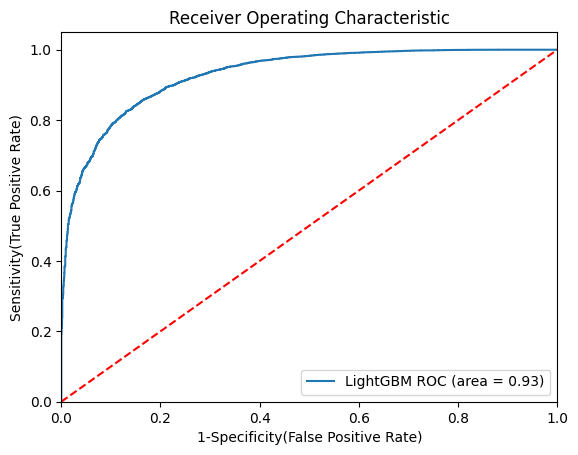

In [135]:
## Plot ROC AUC Curve
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,roc_curve
plt.figure()

# Add the models 
auc_models = [
{
    'label': 'LightGBM',
    'model': best_model,
    "auc" : 0.9296
},
    
]
#loop through model
for algo in auc_models:
    model = algo['model']
    model.fit(X_train_resampled, Y_train_resampled) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(x_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 